# Customer Churn Prediction — Model Training

**Goal:** Build an end-to-end classification pipeline that predicts whether a customer will churn (`Yes`/`No`), evaluate multiple models, and save the winning preprocessing + model pipeline as `churn_pipeline.pkl` for use in the Streamlit app.

## 1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Preprocessing / modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

# Model saving
import joblib

import warnings

# Ignore all warnings globally
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load and Understand the Data

In [2]:
df = pd.read_csv("customer_churn_data.csv")
print("Data loaded.")

Data loaded.


**First 5 rows**

In [3]:
df.head()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


**Last 5 rows**

In [4]:
df.tail()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


**Rows and columns**

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1220
Columns: 17


**Column names**

In [6]:
print(list(df.columns))

['customer_id', 'age', 'gender', 'region', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb', 'churn']


**Data types**

In [7]:
df.dtypes

customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

**Dataset info**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1220 non-null   object 
 1   age                      1220 non-null   int64  
 2   gender                   1220 non-null   object 
 3   region                   1220 non-null   object 
 4   tenure_months            1220 non-null   int64  
 5   monthly_charges          1198 non-null   float64
 6   total_charges            1187 non-null   float64
 7   contract_type            1220 non-null   object 
 8   internet_service         1220 non-null   object 
 9   tech_support             1194 non-null   object 
 10  online_security          1199 non-null   object 
 11  paperless_billing        1220 non-null   object 
 12  payment_method           1200 non-null   object 
 13  num_support_calls        1220 non-null   int64  
 14  late_payments_last_year 

**Descriptive statistics**

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1220,1200,CUST10460,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1220.0,NaN,NaN,NaN,49.309016,18.125678,18.0,34.0,49.5,65.0,80.0
gender,1220,2,Male,625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1220,4,South,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,1220.0,NaN,NaN,NaN,36.956557,20.51256,1.0,19.0,38.0,55.0,72.0
monthly_charges,1198.0,NaN,NaN,NaN,66.509474,24.295211,18.0,50.0475,69.02,86.465,118.58
total_charges,1187.0,NaN,NaN,NaN,2421.133437,1681.896803,12.6,1011.74,2120.45,3619.765,7579.28
contract_type,1220,3,Month-to-month,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,1220,3,Fiber optic,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tech_support,1194,3,No,582,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Quality Checks

**Missing values per column**

In [10]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

**Duplicate records**

In [11]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer_id values:", df['customer_id'].duplicated().sum())

Duplicate rows: 20
Duplicate customer_id values: 20


**Unique values in categorical columns**

In [12]:
cat_cols_preview = df.select_dtypes(include=['object', 'string']).columns.tolist()
for c in cat_cols_preview:
    print(f"{c}: {df[c].unique()}")

customer_id: ['CUST10001' 'CUST10002' 'CUST10003' ... 'CUST11198' 'CUST11199'
 'CUST11200']
gender: ['Female' 'Male']
region: ['East' 'West' 'North' 'South']
contract_type: ['Two year' 'One year' 'Month-to-month']
internet_service: ['DSL' 'Fiber optic' 'No']
tech_support: ['Yes' 'No' 'No internet service' nan]
online_security: ['Yes' 'No' 'No internet service' nan]
paperless_billing: ['No' 'Yes']
payment_method: ['Electronic check' 'Bank transfer' 'Credit card' 'Mailed check' nan]
churn: ['No' 'Yes']


**Class distribution of the target (`churn`)**

In [13]:
df['churn'].value_counts()
print(df['churn'].value_counts(normalize=True) * 100)

churn
Yes    56.393443
No     43.606557
Name: proportion, dtype: float64


## 4. Data Cleaning

**Decisions made (and why):**

- **Duplicate records:** 20 fully duplicated rows (all columns identical, including `customer_id`) were found.
  These are exact re-entries of the same customer record, so they are **dropped** — keeping them would let the
  same customer's pattern be counted twice and bias the model.
- **Missing numeric values** (`monthly_charges`, `total_charges`, `avg_monthly_usage_gb`): left as `NaN` here and
  handled **inside the modeling pipeline** with median imputation, so the exact same transformation is
  automatically re-applied at prediction time in the Streamlit app.
- **Missing categorical values:**
  - `tech_support` / `online_security` are missing only for customers who plausibly have no internet service —
    these are filled with the explicit label `"No internet service"` to match the other categories already
    present in the data, rather than an arbitrary mode fill.
  - `payment_method` has no logical "missing" category, so it is imputed with the **most frequent value**
    inside the pipeline.
- **`customer_id`:** this is a unique identifier with no predictive value (it would only let the model
  memorize individual rows), so it is **removed** before training.


In [14]:
# Drop exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

# Fill structurally-missing categorical values with an explicit label
df['tech_support'] = df['tech_support'].fillna('No internet service')
df['online_security'] = df['online_security'].fillna('No internet service')

# Remove identifier column (no predictive value)
df = df.drop(columns=['customer_id'])

print("Remaining missing values:")
print(df.isnull().sum())

Shape after removing duplicates: (1200, 17)
Remaining missing values:
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            21
total_charges              33
contract_type               0
internet_service            0
tech_support                0
online_security             0
paperless_billing           0
payment_method             19
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64


## 5. Exploratory Data Analysis

**Churn class distribution**

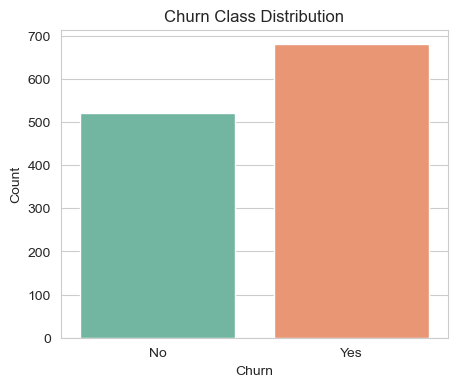

In [15]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Churn Class Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

*Observation:* Churn is **moderately imbalanced** — more customers churned (`Yes`) than stayed in this sample, so accuracy alone should not be the only metric used for evaluation.

**Churn by contract type**

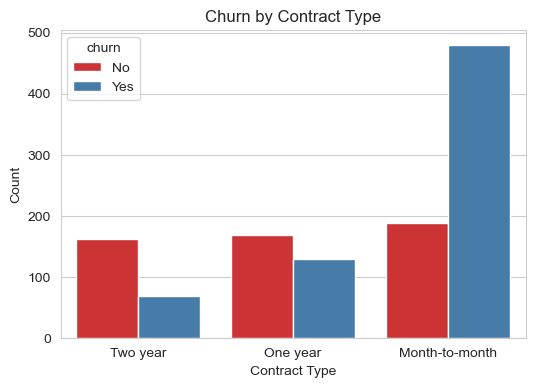

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='contract_type', hue='churn', palette='Set1')
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

*Observation:* Customers on **month-to-month** contracts churn far more than those on one-year or two-year contracts — contract length looks like a strong churn signal.

**Churn by internet service**

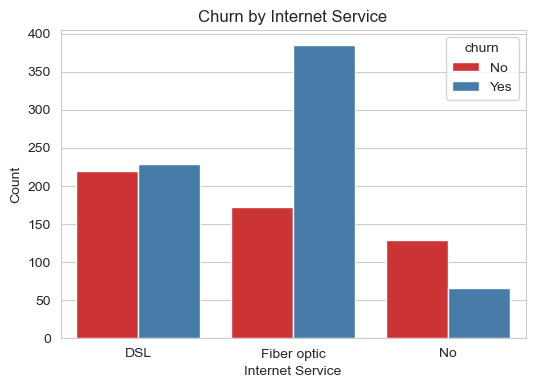

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='internet_service', hue='churn', palette='Set1')
plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

*Observation:* **Fiber optic** customers show a noticeably higher churn rate than DSL or no-internet customers, possibly reflecting higher prices or service issues on that tier.

**Monthly charges distribution**

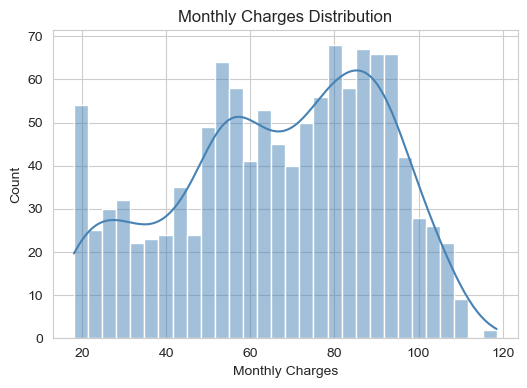

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df['monthly_charges'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.show()

*Observation:* Monthly charges are spread fairly broadly with **no extreme outliers**, so no special outlier handling is needed for this feature.

**Tenure distribution**

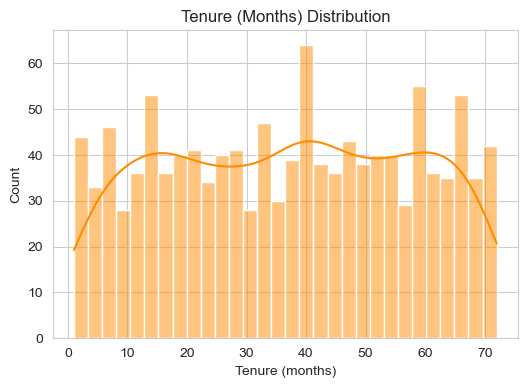

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df['tenure_months'].dropna(), bins=30, kde=True, color='darkorange')
plt.title('Tenure (Months) Distribution')
plt.xlabel('Tenure (months)')
plt.show()

*Observation:* There is a large group of customers with **short tenure**, consistent with newer customers being more likely to churn early.

**Additional visualization: churn rate by payment method**

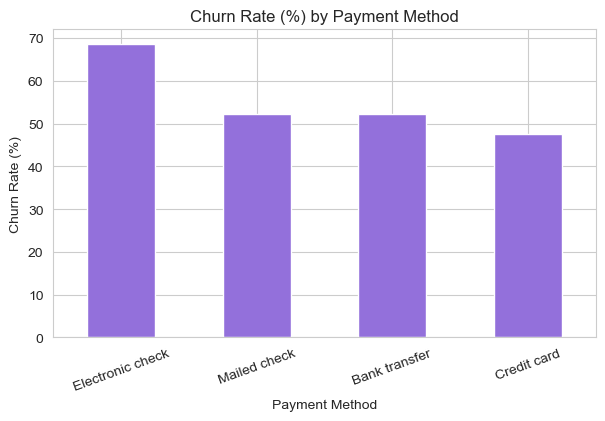

In [20]:
plt.figure(figsize=(7,4))
churn_rate = df.groupby('payment_method')['churn'].apply(lambda s: (s == 'Yes').mean() * 100)
churn_rate.sort_values(ascending=False).plot(kind='bar', color='mediumpurple')
plt.title('Churn Rate (%) by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Payment Method')
plt.xticks(rotation=20)
plt.show()

*Observation:* Customers paying by **electronic check** churn at a visibly higher rate than those using automatic payment methods like bank transfer or credit card.

## 6. Prepare Features and Target

In [21]:
X = df.drop(columns=['churn'])
y = df['churn'].map({'Yes': 1, 'No': 0})

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb']
Categorical features: ['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method']


## 7. Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (960, 15)
Test shape: (240, 15)


## 8. Preprocessing

A `ColumnTransformer` handles numeric and categorical columns differently, wrapped inside a single
`Pipeline` so training-time and prediction-time preprocessing are always identical:

- **Numeric columns:** median imputation for missing values, then standard scaling.
- **Categorical columns:** most-frequent imputation for missing values, then one-hot encoding
  (`handle_unknown='ignore'` so the Streamlit app never crashes on an unseen category).


In [23]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print("Preprocessor ready.")

Preprocessor ready.


## 9. Train At Least Two Models

Logistic Regression, Random Forest, and Decision Tree are trained and compared.

In [24]:
candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42)
}

fitted_pipelines = {}
for name, model in candidate_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: Decision Tree


## 10. Model Evaluation

In [25]:
results = []
for name, pipe in fitted_pipelines.items():
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n===== {name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nClassification Report:")
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1})

comparison_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False).reset_index(drop=True)
comparison_df


===== Logistic Regression =====
Confusion Matrix:
[[ 70  34]
 [ 24 112]]

Classification Report:
              precision    recall  f1-score   support

          No       0.74      0.67      0.71       104
         Yes       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240


===== Random Forest =====
Confusion Matrix:
[[ 66  38]
 [ 33 103]]

Classification Report:
              precision    recall  f1-score   support

          No       0.67      0.63      0.65       104
         Yes       0.73      0.76      0.74       136

    accuracy                           0.70       240
   macro avg       0.70      0.70      0.70       240
weighted avg       0.70      0.70      0.70       240


===== Decision Tree =====
Confusion Matrix:
[[61 43]
 [37 99]]

Classification Report:
              precision    recall  f1-score   support

          No 

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.758333,0.767123,0.823529,0.794326
1,Random Forest,0.704167,0.730496,0.757353,0.743682
2,Decision Tree,0.666667,0.697183,0.727941,0.712230


## 11. Select the Final Model

The models are compared on **F1 score** (not training accuracy), since F1 balances precision and recall and
is more informative on a moderately imbalanced churn target — missing an actual churner (low recall) and
wrongly flagging a loyal customer (low precision) are both costly for a retention team. The model with the
highest F1 score on the **held-out test set** is selected as the final model.


In [26]:
best_model_name = comparison_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
print("Selected final model:", best_model_name)
print(comparison_df)

Selected final model: Logistic Regression
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.758333   0.767123  0.823529  0.794326
1        Random Forest  0.704167   0.730496  0.757353  0.743682
2        Decision Tree  0.666667   0.697183  0.727941  0.712230


## 12. Save the Final Model

In [27]:
joblib.dump(best_pipeline, 'churn_pipeline.pkl')
print("Saved trained pipeline to churn_pipeline.pkl")

Saved trained pipeline to churn_pipeline.pkl


## 13. Reload and Test the Saved Model

In [28]:
loaded_pipeline = joblib.load('churn_pipeline.pkl')

# Manual prediction using one real test-set customer
sample_customer = X_test.iloc[[0]]
prediction = loaded_pipeline.predict(sample_customer)[0]
label = 'Yes' if prediction == 1 else 'No'

print("Sample customer input:")
print(sample_customer.to_dict(orient='records')[0])
print("\nPredicted churn:", label)

if hasattr(loaded_pipeline, 'predict_proba'):
    proba = loaded_pipeline.predict_proba(sample_customer)[0]
    print(f"Prediction confidence -> No: {proba[0]:.2%}, Yes: {proba[1]:.2%}")

print("\nReload test successful — the saved .pkl file works correctly and is ready for the Streamlit app.")

Sample customer input:
{'age': 73, 'gender': 'Male', 'region': 'North', 'tenure_months': 19, 'monthly_charges': 42.43, 'total_charges': 758.01, 'contract_type': 'Month-to-month', 'internet_service': 'DSL', 'tech_support': 'Yes', 'online_security': 'No', 'paperless_billing': 'No', 'payment_method': 'Mailed check', 'num_support_calls': 3, 'late_payments_last_year': 0, 'avg_monthly_usage_gb': 106.4}

Predicted churn: Yes
Prediction confidence -> No: 39.15%, Yes: 60.85%

Reload test successful — the saved .pkl file works correctly and is ready for the Streamlit app.
